# Apples 2

### Imports

In [1]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model 

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

### Data

In [2]:
months = [
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512"
]

my_files = [
    [f"../data/processed/audusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/audusd_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/nzdusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/nzdusd_dukascopy_bid_{m}.parquet" for m in months]
]

### SPREAD

In [3]:
builder = SPREAD(threshold=1000) 
df = builder.build(my_files)

print(df.head(5))

built 15455 rows
                                   Asset_A   Asset_B     Log_A     Log_B  \
timestamp                                                                  
2025-01-02 10:20:10.133000+00:00  0.621755  0.561855 -0.475209 -0.576511   
2025-01-02 10:25:55.560000+00:00  0.621930  0.561855 -0.474928 -0.576511   
2025-01-02 10:32:05.618000+00:00  0.621680  0.561780 -0.475330 -0.576645   
2025-01-02 10:34:14.918000+00:00  0.621880  0.561780 -0.475008 -0.576645   
2025-01-02 10:38:25.397000+00:00  0.621690  0.561840 -0.475314 -0.576538   

                                  Return_A  Return_B  
timestamp                                             
2025-01-02 10:20:10.133000+00:00  0.000265  0.000027  
2025-01-02 10:25:55.560000+00:00  0.000281  0.000000  
2025-01-02 10:32:05.618000+00:00 -0.000402 -0.000133  
2025-01-02 10:34:14.918000+00:00  0.000322  0.000000  
2025-01-02 10:38:25.397000+00:00 -0.000306  0.000107  


### ENGINE

In [4]:
df['Date'] = df.index.date
unique_days = df['Date'].unique()

train_days = 30 
print_freq = 10  # Set how often you want a daily update
out_of_sample_results = []
parameter_tracker = [] 

# The Walk-Forward Loop
for i in range(train_days, len(unique_days)):
    train_dates = unique_days[i - train_days : i]
    test_date = unique_days[i]
    
    train_df = df[df['Date'].isin(train_dates)].copy()
    test_df = df[df['Date'] == test_date].copy()
    
    # Fit Models
    engine = ENGINE(train_df)
    train_fitted = engine.fit_cointegration(z_window=250)
    engine.fit_ar_reversion(lags=1)
    engine.fit_garch_vol(scaling=10000)
    engine.fit_markov_regimes(k_regimes=2)
    
    # Predict Out-of-Sample
    oos_predictions = engine.predict_oos(test_df, engine.data, z_window=250)
    out_of_sample_results.append(oos_predictions)
    
    # Track the Daily Parameters
    parameter_tracker.append({
        'Date': test_date,
        'Beta': engine.beta,
        'Alpha': engine.alpha,
        'Safe_Variance': engine.safe_variance,
        'Danger_Variance': engine.danger_variance,
        'GARCH_Vol': engine.forecasted_vol,
        'AR_Phi': engine.ar_phi
    })

    # --- NEW: SMART PRINTOUTS ---
    # 1. Print when a new month rolls over
    if i > train_days and test_date.month != unique_days[i-1].month:
        print(f"\n📅 --- ENTERING {test_date.strftime('%B %Y').upper()} ---")
        
    # 2. Print periodic updates (Every N days)
    if i % print_freq == 0:
        print(f"[{test_date}] Beta: {engine.beta:>6.4f} | GARCH Vol: {engine.forecasted_vol:>5.2f} | AR_Phi: {engine.ar_phi:>6.4f}")

# Stitch data together
live_trading_data = pd.concat(out_of_sample_results)
df_params = pd.DataFrame(parameter_tracker).set_index('Date') 

print(f"\n🎉 OOS Dataset Built: {len(live_trading_data)} rows.")
print("📊 Parameter tracking complete.")

Cointegration Fitted | Beta: 0.9434 | Alpha: 0.0690
Markov Fitted | Danger Variance: 810.85 | Safe Variance: 14.22
[2025-02-13] Beta: 0.9434 | GARCH Vol:  5.67 | AR_Phi: 0.9400
Cointegration Fitted | Beta: 0.9442 | Alpha: 0.0695
Markov Fitted | Danger Variance: 772.83 | Safe Variance: 14.15
Cointegration Fitted | Beta: 0.9758 | Alpha: 0.0877
Markov Fitted | Danger Variance: 1121.98 | Safe Variance: 14.88
Cointegration Fitted | Beta: 0.9785 | Alpha: 0.0892
Markov Fitted | Danger Variance: 1281.39 | Safe Variance: 14.80
Cointegration Fitted | Beta: 0.9996 | Alpha: 0.1015
Markov Fitted | Danger Variance: 1326.49 | Safe Variance: 15.45
Cointegration Fitted | Beta: 1.0144 | Alpha: 0.1100
Markov Fitted | Danger Variance: 1134.36 | Safe Variance: 15.15
Cointegration Fitted | Beta: 1.0424 | Alpha: 0.1261
Markov Fitted | Danger Variance: 1208.98 | Safe Variance: 15.74
Cointegration Fitted | Beta: 1.0606 | Alpha: 0.1365
Markov Fitted | Danger Variance: 1265.09 | Safe Variance: 15.81
Cointegratio

### BACKTEST

In [5]:
bt = BACKTESTER(live_trading_data)

# We use the relaxed constraints that worked well for you
results_df = bt.run(
    base_z=1.5, 
    exit_z=0.0, 
    danger_threshold=0.6, 
    ar_limit=0.995, 
    fee_bps=0.5
)

### TEARSHEET


           INSTITUTIONAL PERFORMANCE REPORT            
Metric                    | Adaptive     | Static Base 
-------------------------------------------------------
Total Return (Bps)        | 427.72       | 2471.47     
Annual Vol (Bps)          | 472.51       | 787.37      
Sharpe Ratio              | 1.00         | 3.45        
Sortino Ratio             | 0.79         | 3.63        
Max Drawdown (Bps)        | -263.58      | -271.38     
Calmar Ratio              | 1.62         | 9.11        
Win Rate                  | 48.34%       | 50.20%      
Profit Factor             | 1.05         | 1.15        



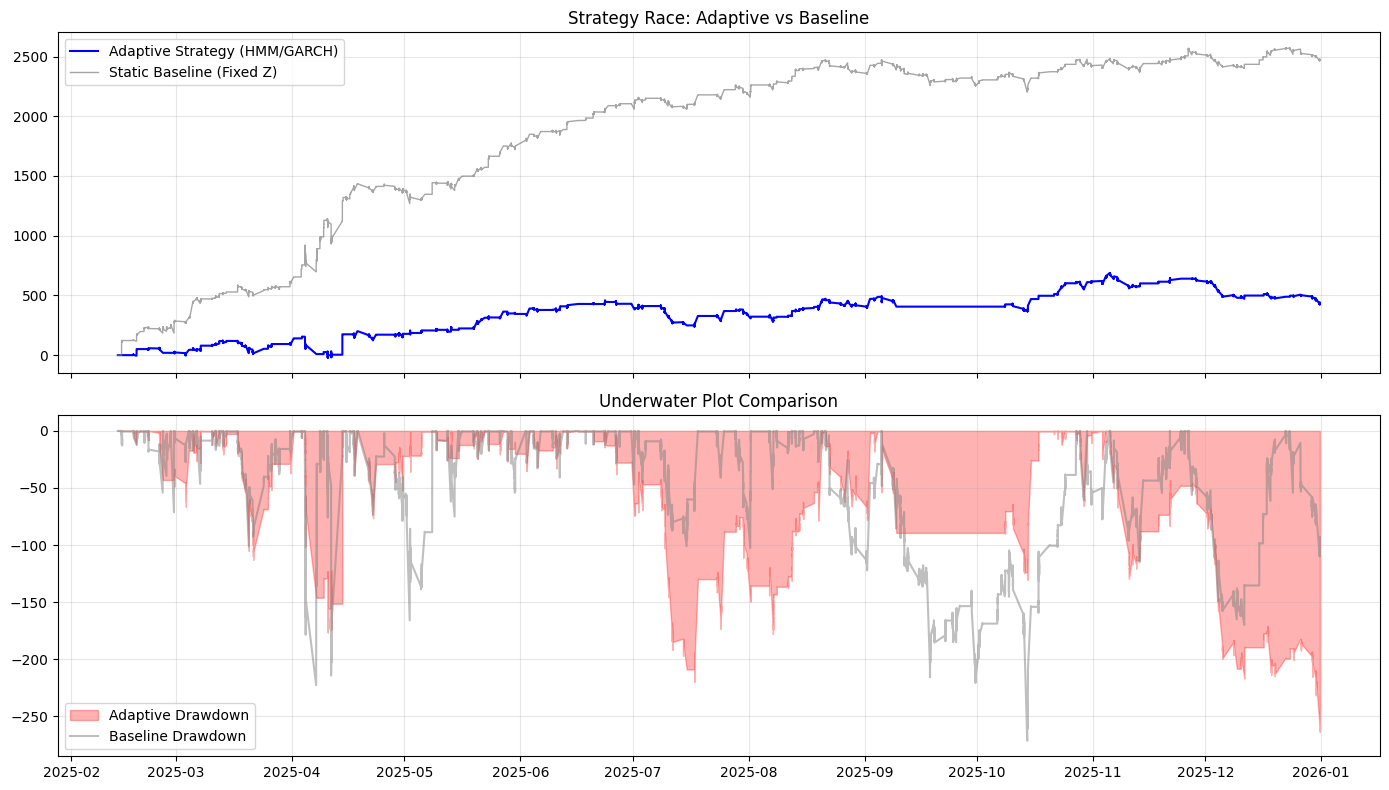

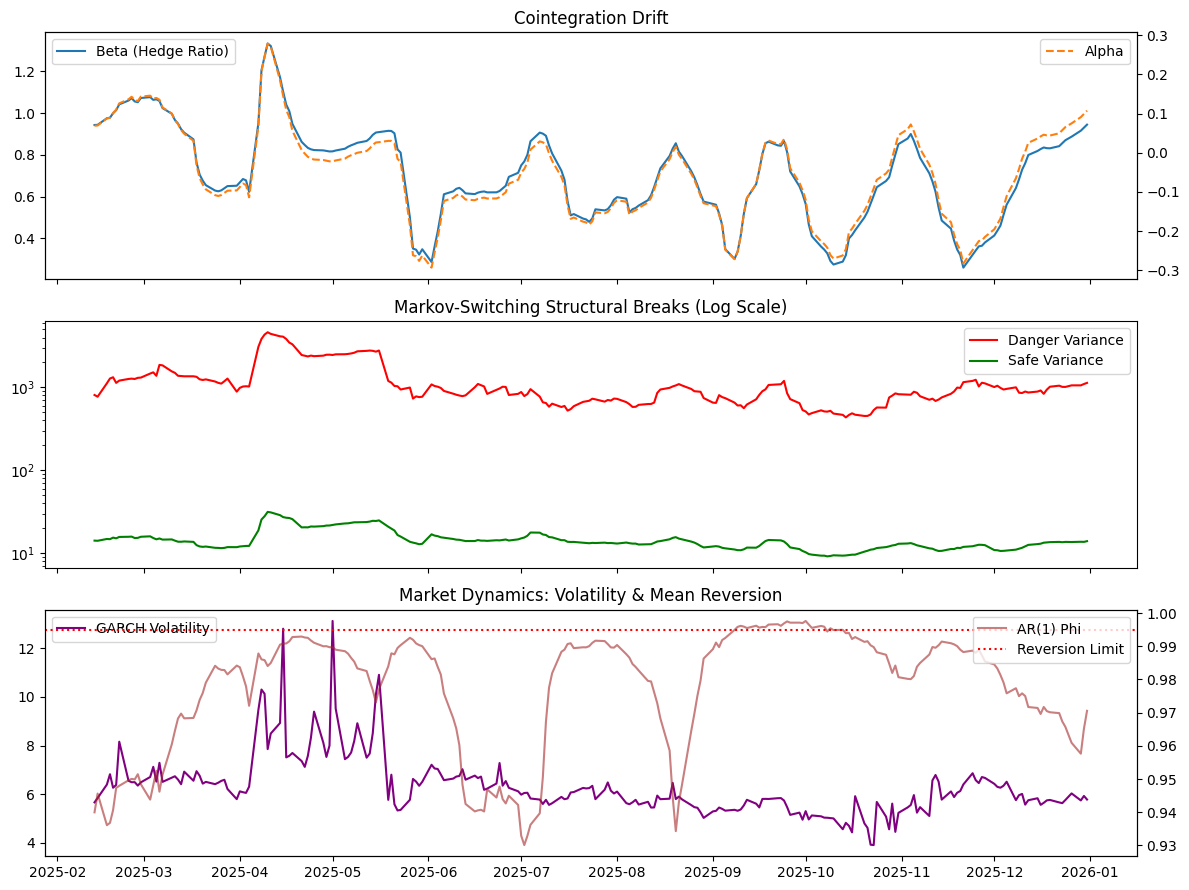

In [6]:
# 1. Initialize Tearsheet WITH the tracked parameters
ts = TEARSHEET(results_df, df_params=df_params)

# 2. Print the side-by-side Institutional metrics
ts.generate_report()

# 3. Plot the Strategy vs Baseline equity curve
ts.plot_comparative_equity()

# 4. Plot the inner workings of the ENGINE
ts.plot_engine_parameters()